In [2]:
%pip install --no-deps  git+https://github.com/ocean-colour/xqaa.git
%pip install --no-deps  git+https://github.com/ocean-colour/ocpy.git

  Cloning https://github.com/ocean-colour/xqaa.git to /tmp/pip-req-build-4dov1dj_
  Running command git clone --filter=blob:none --quiet https://github.com/ocean-colour/xqaa.git /tmp/pip-req-build-4dov1dj_
  Resolved https://github.com/ocean-colour/xqaa.git to commit 12d8966e88a661634b65f44af7876bb7bae63ce9
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
Note: you may need to restart the kernel to use updated packages.
  Cloning https://github.com/ocean-colour/ocpy.git to /tmp/pip-req-build-kzfu945t
  Running command git clone --filter=blob:none --quiet https://github.com/ocean-colour/ocpy.git /tmp/pip-req-build-kzfu945t
  Resolved https://github.com/ocean-colour/ocpy.git to commit da55e1a443593b59526e12e0319dae5634f53556
  Preparing metadata (setup.py) ... done
Note: you may need to restart the kernel to use updated packages.


# Initialization

In [13]:
import os
import glob
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
from xqaa import geometric as xqaa_geom
from xqaa import inversion
from xqaa.params import XQAAParams
import seaborn as sns
from matplotlib.lines import Line2D
from scipy.stats import ttest_ind, mannwhitneyu, pointbiserialr
import matplotlib.colors as mcolors
from scipy.stats import linregress, spearmanr
#constants
bbox = (-118, 32, -117, 33)  # west, south, east, north
AOP_CLIP_DIR = "granule_cache/aop_clipped"   
PICKS_PATH = "chl_transect_picks.csv"        
N_FETCH_MAX = 50
N_NEAREST = 20
WAVE_MIN, WAVE_MAX = 400.0, 700.0

df = pd.read_csv(PICKS_PATH, parse_dates=["date"])

# Data Loading 
converts from lat long to xyz for easy pixle matching and opens clipped granule from granule cache(folder)

In [4]:
# converts lat long to xyz for nearest pixle selection
def latlon_to_xyz(lat, lon):
    lat_r, lon_r = np.radians(lat), np.radians(lon)
    x = np.cos(lat_r) * np.cos(lon_r)
    y = np.cos(lat_r) * np.sin(lon_r)
    z = np.sin(lat_r)
    return np.stack([x, y, z], axis=-1)

# Reads the already-clipped AOP file for selected date
def get_clipped_granule(date_str):
    matches = glob.glob(os.path.join(AOP_CLIP_DIR, f"aop_clipped_{date_str}.nc"))
    if not matches:
        raise ValueError(f"No clipped AOP granule for {date_str} in {AOP_CLIP_DIR}")
    return xr.open_dataset(matches[0], chunks={})  # flat dataset (dims: y, x, wavelength)
    

# Data cleaning 
matches chl bin sample points to the nearest valid satellite pixels, per date, and outputs DF wiht spectral values

In [5]:

records = []
west, south, east, north = bbox

#looks up date in data
for date_str, group_rows in df.groupby(df["date"].dt.strftime("%Y-%m-%d")):
    try: #Fetch that date's satellite granule; skip the date if it fails
        ds = get_clipped_granule(date_str)
    except ValueError as e:
        print(f"Skipping date {date_str}: {e}")
        continue
# Pull out the lat/lon grids created in cell above, the wavelength axis, and keep Rrs as an xarray
    lat_grid = ds["latitude"].values
    lon_grid = ds["longitude"].values
    wavelengths = ds["wavelength"].values
    rrs_da = ds["Rrs"]
    
# creates mask over bbox for land and ice/clouds
    BAD_BITS = (1 << 1) | (1 << 9)  # LAND | CLDICE
    flags_grid = ds["l2_flags"].values.astype(int)
    mask = (
        (lat_grid >= south) & (lat_grid <= north) &
        (lon_grid >= west) & (lon_grid <= east) &
        ((flags_grid & BAD_BITS) == 0) )
    
    ys, xs = np.where(mask)

# converts valid pixels' lat/lon to 3D Cartesian coordinates for distance
    xyz_grid = latlon_to_xyz(lat_grid[ys, xs], lon_grid[ys, xs])  # (M, 3)

# check for rows missing lat/lon/chl; logs and drops them.
    valid = group_rows[["lat", "lon", "chl"]].notna().all(axis=1)
    for idx, r in group_rows[~valid].iterrows():
        print(f"Skipping row_idx={idx} ({r['group']}, {r['date'].date()}, {r['level']}): NaN chl/lat/lon")
    group_rows = group_rows[valid]

# converts  sample points' lat/lon to the same 3D Cartesian system.
    target_xyz = latlon_to_xyz(group_rows["lat"].values, group_rows["lon"].values)  # (n_rows, 3)

# distance from every sample point to every valid pixel
    d = np.linalg.norm(target_xyz[:, None, :] - xyz_grid[None, :, :], axis=2)  # (n_rows, M)
    flat_idx = np.argsort(d, axis=1)[:, :N_FETCH_MAX] # Sorts each row's distances                          # (n_rows, k)
    dist_km = np.take_along_axis(d, flat_idx, axis=1) * 6371.0 # Pulls out the actual distance values at those sorted positions                 # (n_rows, k)

# maps the nearest-neighbor indices
    sel_y = ys[flat_idx]   # (n_rows, k)
    sel_x = xs[flat_idx]   # (n_rows, k)

#  fetches the Rrs spectrum at every selected (y, x) pair
    spectra = rrs_da.isel(
        y=xr.DataArray(sel_y, dims=("pt", "k")),
        x=xr.DataArray(sel_x, dims=("pt", "k")),).values   # (n_rows, k, n_wave)

# marks which (row, rank) pairs have at least one non-NaN wavelength value
    n_wave = spectra.shape[2]
    good = ~np.all(np.isnan(spectra), axis=2)
    row_i, rank_j = np.where(good)
    
# selects metadata for each row
    meta = group_rows.iloc[row_i].reset_index()
    
#appends the data frame wiht updated vales 
    records.append(pd.DataFrame({
        "row_idx":       np.repeat(meta["index"].values, n_wave),
        "group":         np.repeat(meta["group"].values, n_wave),
        "date":          np.repeat(meta["date"].values, n_wave),
        "level":         np.repeat(meta["level"].values, n_wave),
        "chl":           np.repeat(meta["chl"].values, n_wave),
        "pixel_rank":    np.repeat(rank_j, n_wave),
        "pixel_dist_km": np.repeat(dist_km[row_i, rank_j], n_wave),
        "wavelength":    np.tile(wavelengths, len(row_i)),
        "rrs":           spectra[row_i, rank_j, :].ravel(),}))
    
# closes and cleans up opened dfs 
    ds.close()
    del lat_grid, lon_grid, rrs_da, ds
    
# consolidates into one long df
rrs_long = pd.concat(records, ignore_index=True) if records else pd.DataFrame()
print(f"Fetched {len(rrs_long)} spectral records across {rrs_long['row_idx'].nunique()} rows")

Skipping row_idx=0 (No PS but High CH, 2024-03-15, low): NaN chl/lat/lon
Skipping row_idx=3 (No PS but High CH, 2024-03-15, very_high): NaN chl/lat/lon
Skipping row_idx=4 (No PS but High CH, 2024-03-17, low): NaN chl/lat/lon
Skipping row_idx=7 (No PS but High CH, 2024-03-17, very_high): NaN chl/lat/lon
Skipping row_idx=10 (No PS but High CH, 2024-04-15, high): NaN chl/lat/lon
Skipping row_idx=11 (No PS but High CH, 2024-04-15, very_high): NaN chl/lat/lon
Skipping row_idx=15 (No PS but High CH, 2024-04-16, very_high): NaN chl/lat/lon
Skipping row_idx=16 (No PS but High CH, 2024-04-19, low): NaN chl/lat/lon
Skipping row_idx=17 (No PS but High CH, 2024-04-19, mid): NaN chl/lat/lon
Skipping row_idx=18 (No PS but High CH, 2024-04-19, high): NaN chl/lat/lon
Skipping row_idx=19 (No PS but High CH, 2024-04-19, very_high): NaN chl/lat/lon
Skipping row_idx=27 (No PS but High CH, 2024-04-28, very_high): NaN chl/lat/lon
Skipping row_idx=34 (Known PS, 2024-04-30, high): NaN chl/lat/lon
Skipping row

In [6]:
df["chl_bin"] = df["level"]  # low / mid / high / very_high, from the pipelineBIN_RANGES

rl = rrs_long[rrs_long["pixel_rank"] < N_NEAREST].copy()
rl["date"] = pd.to_datetime(rl["date"]).dt.normalize()
point_rrs = (
    rl.groupby(["row_idx", "group", "date", "level", "chl", "wavelength"], as_index=False)
      ["rrs"].median())

point_rrs = point_rrs.merge(df[["chl_bin"]], left_on="row_idx", right_index=True, how="left")

# IOP Variable constants

In [7]:
# Needed by XQAA code
#Returns (aw, bbw) interpolated onto `wave` (nm), using NASA's public pure-water absorption/scattering table (Pope & Fry 1997 / Smith & Baker 1981).
WATER_COEF_URL = "https://oceancolor.gsfc.nasa.gov/data/reprocessing/r2009/sources/water_coef.txt"

def get_water_iops(wave, url=WATER_COEF_URL):
    import requests
    resp = requests.get(url, timeout=30)
    resp.raise_for_status()
    text = resp.text
    data_lines = text.split("/end_header", 1)[1].strip().splitlines()
    rows = [line.split() for line in data_lines if line.strip()]
    tbl = pd.DataFrame(rows, columns=["wavelength", "aw", "bw"]).astype(float)
    aw_interp = interp1d(tbl["wavelength"], tbl["aw"],
                          kind="linear", bounds_error=False, fill_value="extrapolate")
    bw_interp = interp1d(tbl["wavelength"], tbl["bw"],
                          kind="linear", bounds_error=False, fill_value="extrapolate")
    aw = aw_interp(wave)
    bbw = 0.5 * bw_interp(wave)
    return aw, bbw

# XQAA 

In [8]:
def restrict_to_visible(wave, Rrs, wmin=WAVE_MIN, wmax=WAVE_MAX):
    mask = (wave >= wmin) & (wave <= wmax)
    return wave[mask], Rrs[mask]

pace_wave = np.sort(point_rrs["wavelength"].unique())
pace_wave_vis = pace_wave[(pace_wave >= WAVE_MIN) & (pace_wave <= WAVE_MAX)]
aw_pace, bbw_pace = get_water_iops(pace_wave_vis)

# actual XQAA calc
def safe_quadratic(rrs, H1, H2):
    with np.errstate(invalid="ignore"):
        sq = np.sqrt(H1**2 + 4 * H2 * rrs)
        upos = (-H1 + sq) / (2 * H2)
        D = np.where(upos > 0, 1.0 / np.where(upos > 0, upos, np.nan) - 1.0, np.nan)
    return D

def rrs_to_bbnw_safe(wave, Rrs, aw, bbw, xparams=None):
    xparams = xparams or XQAAParams()
    rrs = xqaa_geom.rrs_from_Rrs(Rrs)
    G1, G2 = inversion.calc_Gcoeff(wave, xparams)
    D = safe_quadratic(rrs, G1, G2)
    return inversion.retrieve_bbp(aw, bbw, D)   # <-- was retrieve_bbnw

# makes new df with bbnw 
bbnw_records = []
for row_idx, sub in point_rrs.groupby("row_idx", observed=True):
    sub = sub.sort_values("wavelength")
    date = sub["date"].iat[0]
    group = sub["group"].iat[0]
    chl_bin = sub["chl_bin"].iat[0]

    wave_full = sub["wavelength"].values
    Rrs_full = sub["rrs"].values
    wave, Rrs = restrict_to_visible(wave_full, Rrs_full)

    bbnw = rrs_to_bbnw_safe(wave, Rrs, aw_pace, bbw_pace)
    
    bbnw_records.append(pd.DataFrame({
        "row_idx": row_idx,
        "date": date,
        "group": group,
        "chl_bin": chl_bin,
        "wavelength": wave,
        "bbnw": bbnw,}))

bbnw_df = pd.concat(bbnw_records, ignore_index=True)

print(f"Retrieved bbnw for {bbnw_df['row_idx'].nunique()} points ")
    
bbnw_df["pn_status"] = bbnw_df["group"].map({
    "Known PS": "PN",
    "No PS but High CH": "No PN",})

Retrieved bbnw for 518 points 


# Plotting

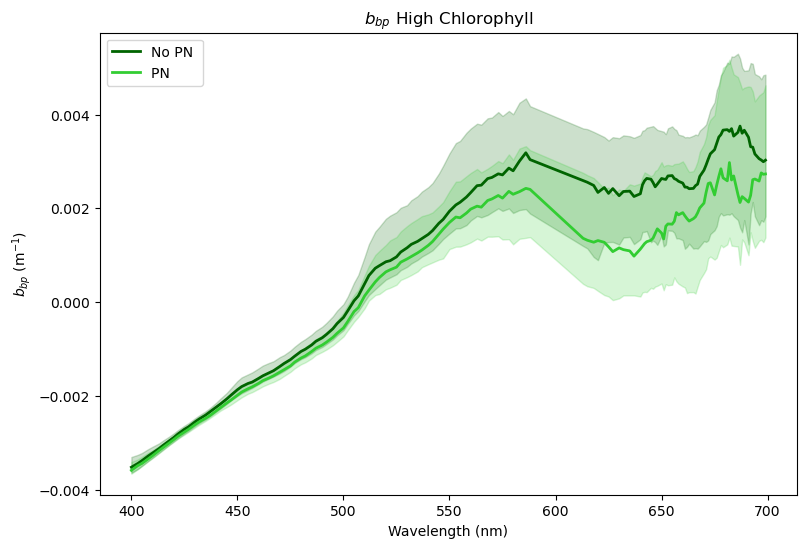

In [9]:
bbnw_df["pn_status"] = bbnw_df["group"].map({
    "Known PS": "PN",
    "No PS but High CH": "No PN"})

colors = {"PN": "limegreen", "No PN": "darkgreen"}

# low  mid  high  very_high,
CHL_SELECTION = "high" 

if CHL_SELECTION == "all":
    plot_df = bbnw_df
    title = "bbnw: PN vs No PN all bins"
    
else:
    plot_df = bbnw_df[bbnw_df["chl_bin"] == CHL_SELECTION]
    title = f"bbp {CHL_SELECTION}"
    
# IQR and actual plotting
fig, ax = plt.subplots(figsize=(9, 6))
for status, sub in plot_df.groupby("pn_status"):
    stats = sub.groupby("wavelength")["bbnw"].agg(
        median="median",
        p25=lambda x: np.nanpercentile(x, 25),
        p75=lambda x: np.nanpercentile(x, 75)).reset_index()

    n = sub["row_idx"].nunique()
    ax.plot(stats["wavelength"], stats["median"], label=f"{status} ", color=colors[status], lw=2)
    ax.fill_between(stats["wavelength"], stats["p25"], stats["p75"], color=colors[status], alpha=0.2)

ax.set_xlabel("Wavelength (nm)")
ax.set_ylabel(r"$b_{bp}$ (m$^{-1}$)")
ax.set_title("$b_{bp}$ High Chlorophyll")
ax.legend()
plt.show()
#print(bbnw_df.groupby("pn_status")["date"].nunique())

# Subplots 

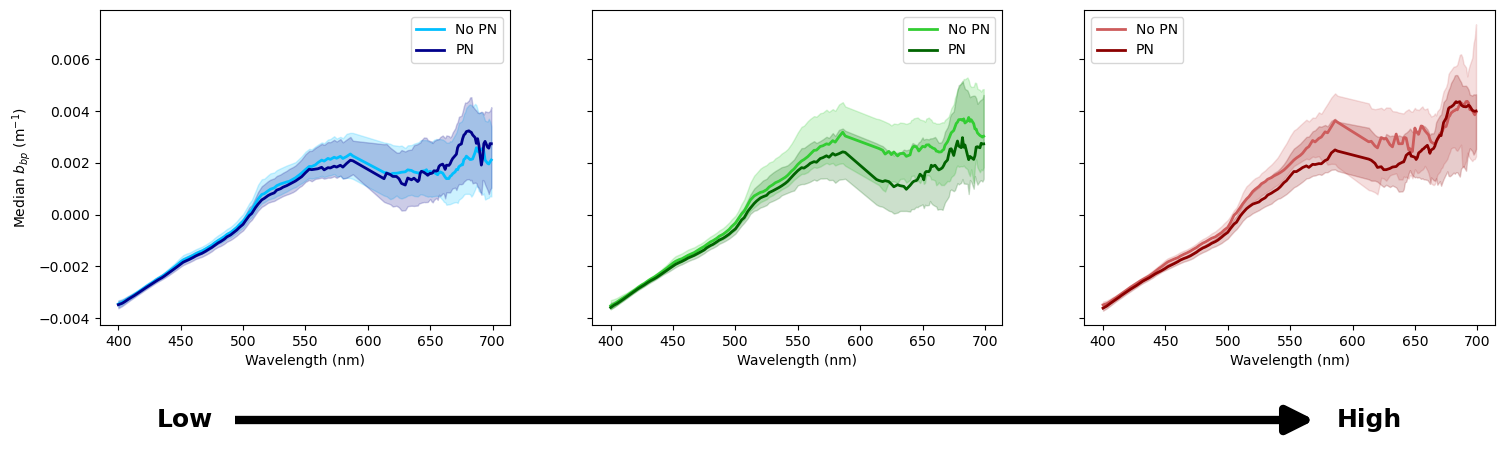

In [27]:
from matplotlib.patches import FancyArrowPatch

bbnw_df["pn_status"] = bbnw_df["group"].map({
    "Known PS": "PN",
    "No PS but High CH": "No PN"
})
chl_bins = ["mid", "high", "very_high"]
bin_base_colors = {
    "mid": "blue",
    "high": "green",
    "very_high": "red",
}
bin_colors = {
    "mid":       {"No PN": "deepskyblue", "PN": "darkblue"},
    "high":      {"No PN": "limegreen",   "PN": "darkgreen"},
    "very_high": {"No PN": "indianred",   "PN": "darkred"},
}
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, chl_bin in zip(axes, chl_bins):
    sub_bin = bbnw_df[bbnw_df["chl_bin"] == chl_bin]
    for status, sub in sub_bin.groupby("pn_status"):
        stats = sub.groupby("wavelength")["bbnw"].agg(
            median="median",
            p25=lambda x: np.nanpercentile(x, 25),
            p75=lambda x: np.nanpercentile(x, 75)).reset_index()
        color = bin_colors[chl_bin][status]
        ax.plot(stats["wavelength"], stats["median"], label=status, color=color, lw=2)
        ax.fill_between(stats["wavelength"], stats["p25"], stats["p75"], color=color, alpha=0.2)
    ax.set_xlabel("Wavelength (nm)")
    ax.legend()
axes[0].set_ylabel(r"Median $b_{bp}$ (m$^{-1}$)")

fig.subplots_adjust(bottom=0.25)

arrow_ax = fig.add_axes([0.2, 0.02, 0.6, 0.08])
arrow_ax.set_xlim(0, 1)
arrow_ax.set_ylim(0, 1)
arrow_ax.axis("off")

arrow = FancyArrowPatch(
    (0, 0.5), (1, 0.5),
    arrowstyle="-|>", mutation_scale=40,
    linewidth=6, color="black",
    shrinkA=0, shrinkB=0,
)
arrow_ax.add_patch(arrow)

arrow_ax.text(-0.02, 0.5, "Low", ha="right", va="center", fontsize=18,
              fontweight="bold")
arrow_ax.text(1.02, 0.5, "High", ha="left", va="center", fontsize=18,
              fontweight="bold")

plt.savefig("XQAA 3 box plot.png", dpi=300, bbox_inches="tight")
plt.show()

# Stats 

Brightness is the average  value across all wavelengths  for each sample pointr epresenting how bright or dim that point's overall spectrum is. R² is the squared point biserial correlation between groups  what proportion of the variation in brightness across all your points is explained by what group

SAM  measures the angle between a sample point's spectrum and a reference spectrum (the median No-PN spectrum), capturing how different that point's spectral shape is from a typical non bloom spectrum


## Brightness Box Plot

/tmp/ipykernel_554/2575400207.py:36: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])


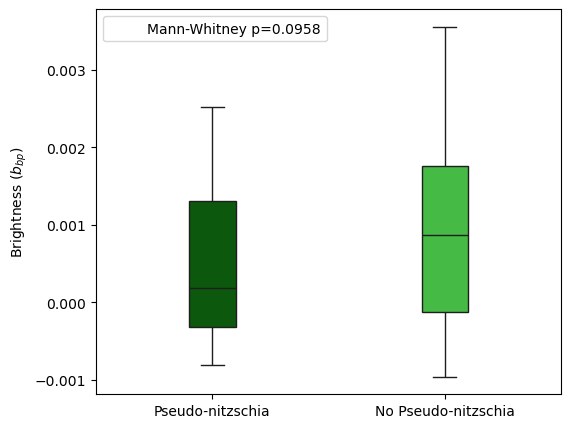

In [22]:

CHL_BIN = "high"  # "low", "mid", "high", "very_high", or None for all bins combined
# set wavelength window
bbnw_df_restricted = bbnw_df[(bbnw_df["wavelength"] >= 400) & (bbnw_df["wavelength"] <= 700)]
# filter by chl_bin unless None
if CHL_BIN is not None:
    bbnw_df_restricted = bbnw_df_restricted[bbnw_df_restricted["chl_bin"] == CHL_BIN]

# groups by PN status and then takes mean of bbnw value as brightness value
point_stats_brightness = bbnw_df_restricted.groupby("row_idx").agg(
    pn_status=("pn_status", "first"),
    brightness=("bbnw", "mean"),).reset_index()

# sets categories for PN status
pn = point_stats_brightness[point_stats_brightness["pn_status"] == "PN"]
no_pn = point_stats_brightness[point_stats_brightness["pn_status"] == "No PN"]

#  paired with Mann-Whitney U
def rank_biserial(group1, group2):
    result = mannwhitneyu(group1, group2)
    u_stat = result.statistic
    p_value = result.pvalue
    n1, n2 = len(group1), len(group2)
    r = 1 - (2 * u_stat) / (n1 * n2)
    return u_stat, p_value, r

u_stat, u_p, rank_biserial_r = rank_biserial(
    pn["brightness"].dropna(),
    no_pn["brightness"].dropna())

# plotting
fig, ax = plt.subplots(figsize=(6, 5))
box_colors = {"PN": "darkgreen", "No PN": "limegreen"}
sns.boxplot(data=point_stats_brightness, x="pn_status", y="brightness", ax=ax,
            order=["PN", "No PN"], showfliers=False, width=0.2,
            hue="pn_status", palette=box_colors, legend=False)
ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])
legend_elements = [
    Line2D([0], [0], color="none", label=f"Mann-Whitney p={u_p:.3g}"),
   # Line2D([0], [0], color="none", label=f"Rank-biserial r = {rank_biserial_r:.3f}"),
]
ax.legend(handles=legend_elements, loc="upper left")
title_suffix = CHL_BIN if CHL_BIN is not None else "all bins"
#ax.set_title("Brightness $b_{bp}$")
ax.set_ylabel("Brightness ($b_{bp}$)")
ax.set_xlabel("")
plt.savefig("XQAA BRightness box plot.png", dpi=300, bbox_inches="tight")
plt.show()

# shows how many points per sample
#print(point_stats_brightness.groupby("pn_status").size())

## SAM boxplot

/tmp/ipykernel_554/3229392535.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])


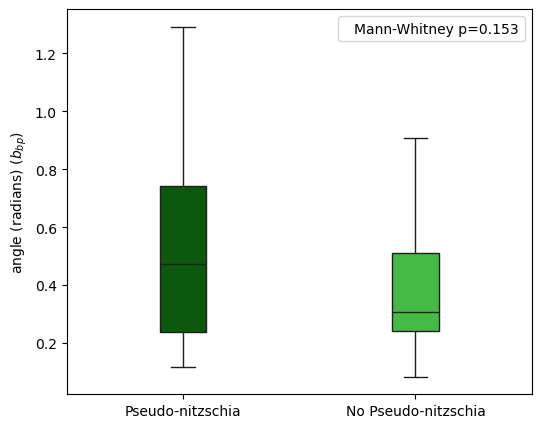

In [21]:
CHL_BIN = "high"  # "low", "mid", "high", "very_high", or None for all bins combined
bbnw_df_restricted = bbnw_df[(bbnw_df["wavelength"] >= 400) & (bbnw_df["wavelength"] <= 700)]
if CHL_BIN is not None:
    bbnw_df_restricted = bbnw_df_restricted[bbnw_df_restricted["chl_bin"] == CHL_BIN]

# reference spectrum: median No PN spectrum, per wavelength
reference = (bbnw_df_restricted[bbnw_df_restricted["pn_status"] == "No PN"]
             .groupby("wavelength")["bbnw"].median()
             .sort_index())

# pivot to one row per point, one column per wavelength, aligned to the reference's wavelengths
wide = bbnw_df_restricted.pivot_table(index="row_idx", columns="wavelength", values="bbnw")

def spectral_angle(row, ref):
    row = row.values
    valid = ~np.isnan(row)
    if valid.sum() < 2:
        return np.nan
    r, s = ref.values[valid], row[valid]
    cos_theta = np.dot(s, r) / (np.linalg.norm(s) * np.linalg.norm(r))
    cos_theta = np.clip(cos_theta, -1, 1)
    return np.arccos(cos_theta)

sam_vals = wide.apply(lambda row: spectral_angle(row, reference), axis=1).rename("sam")
meta = bbnw_df_restricted.groupby("row_idx")["pn_status"].first()
point_stats_sam = pd.concat([meta, sam_vals], axis=1).reset_index()

pn = point_stats_sam[point_stats_sam["pn_status"] == "PN"]
no_pn = point_stats_sam[point_stats_sam["pn_status"] == "No PN"]

# Mann-Whitney U
def Manwhitney(group1, group2):
    result = mannwhitneyu(group1, group2)
    u_stat = result.statistic
    p_value = result.pvalue
    n1, n2 = len(group1), len(group2)
    return u_stat, p_value

u_stat_sam, u_p_sam = Manwhitney(pn["sam"].dropna(), no_pn["sam"].dropna())

fig, ax = plt.subplots(figsize=(6, 5))
box_colors = {"PN": "darkgreen", "No PN": "limegreen"}
sns.boxplot(data=point_stats_sam, x="pn_status", y="sam", ax=ax,
            order=["PN", "No PN"], showfliers=False, width=0.2,
            hue="pn_status", palette=box_colors, legend=False)
ax.set_xticklabels(["Pseudo-nitzschia", "No Pseudo-nitzschia"])
legend_elements = [
    Line2D([0], [0], color="none", label=f"Mann-Whitney p={u_p_sam:.3g}"),
]
ax.legend(handles=legend_elements, loc="upper right", handlelength=0)
#ax.set_title("SAM $b_{bp}$")
ax.set_ylabel("angle (radians) ($b_{bp}$)")
ax.set_xlabel("")
plt.savefig("XQAA SAM box plot.png", dpi=300, bbox_inches="tight")
plt.show()
#print(point_stats_sam.groupby("pn_status").size())

## SAM vs PN CC LR

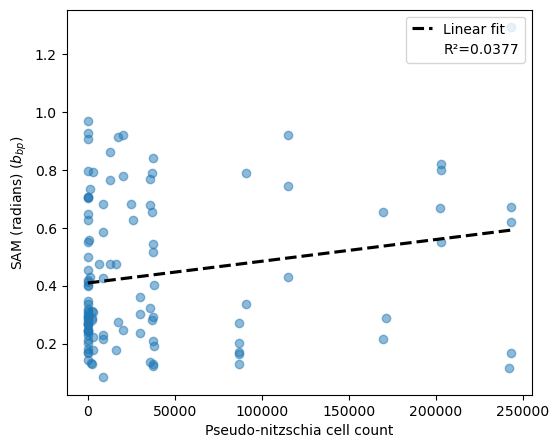

In [26]:

# load and prep count metadata
counts_df = pd.read_csv("chl_transect_picks.csv")
date_counts = counts_df.groupby("date")["count"].first().reset_index()
date_counts["date"] = pd.to_datetime(date_counts["date"])
bbnw_df["date"] = pd.to_datetime(bbnw_df["date"])

# merge count into point_stats_sam
point_stats_sam_counts = point_stats_sam.merge(
    bbnw_df[["row_idx", "date"]].drop_duplicates(), on="row_idx", how="left"
).merge(date_counts, on="date", how="left")

# Part A: presence/absence vs SAM
point_stats_sam_counts["present"] = (point_stats_sam_counts["count"] > 0).astype(int)

# SAM vs count, nonzero only
mask_nz = point_stats_sam_counts["count"].notna() & point_stats_sam_counts["sam"].notna()
x_nz = point_stats_sam_counts.loc[mask_nz, "count"]
y_nz = point_stats_sam_counts.loc[mask_nz, "sam"]

slope, intercept, r_value, p_value, std_err = linregress(x_nz, y_nz)
r_squared = r_value**2
rho, sp_p = spearmanr(x_nz, y_nz)

fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(
    x=x_nz, y=y_nz, ax=ax,
    scatter_kws={"alpha": 0.5, "label": "Observed points"},
    line_kws={"color": "black", "linestyle": "--", "label": "Linear fit"},
    ci=None,
)

# combine the regplot handles with the R² annotation
handles, labels = ax.get_legend_handles_labels()
handles.append(Line2D([0], [0], color="none"))
labels.append(f"R\u00b2={r_squared:.3g}")

ax.legend(handles=handles, labels=labels, loc="upper right", handlelength=1.5)

ax.set_xlabel("Pseudo-nitzschia cell count")
ax.set_ylabel("SAM (radians) ($b_{bp}$)")
plt.savefig("XQAA SAM LR plot.png", dpi=300, bbox_inches="tight")
plt.show()

## Brightness vs PN CC LR 

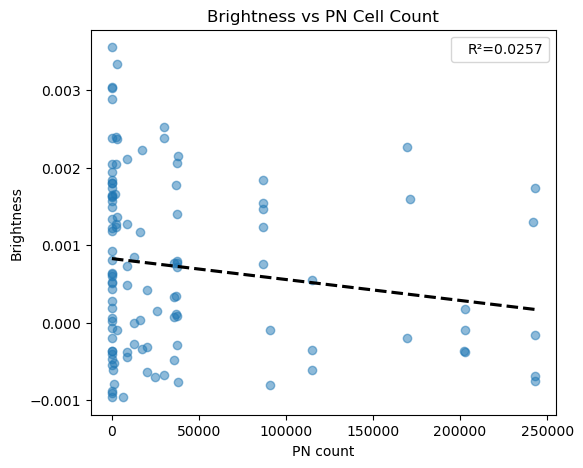

In [15]:
# load and prep count metadata
counts_df = pd.read_csv("chl_transect_picks.csv")
date_counts = counts_df.groupby("date")["count"].first().reset_index()
date_counts["date"] = pd.to_datetime(date_counts["date"])
bbnw_df["date"] = pd.to_datetime(bbnw_df["date"])

# merge count into point_stats_brightness
point_stats_brightness_counts = point_stats_brightness.merge(
    bbnw_df[["row_idx", "date"]].drop_duplicates(), on="row_idx", how="left"
).merge(date_counts, on="date", how="left")

# mask to valid rows with both brightness and count
mask = point_stats_brightness_counts["brightness"].notna() & point_stats_brightness_counts["count"].notna()
x = point_stats_brightness_counts.loc[mask, "count"]
y = point_stats_brightness_counts.loc[mask, "brightness"]

# stats
slope, intercept, r_value, p_value, std_err = linregress(x, y)
r_squared = r_value**2
rho, sp_p = spearmanr(x, y)

# plot
fig, ax = plt.subplots(figsize=(6, 5))
sns.regplot(
    x=x, y=y, ax=ax,
    scatter_kws={"alpha": 0.5},
    line_kws={"color": "black", "linestyle": "--"},
    ci=None,)  # removes the shaded confidence interval

legend_elements = [
    Line2D([0], [0], color="none", label=f"R\u00b2={r_squared:.3g}"),
]
ax.legend(handles=legend_elements, loc="upper right", handlelength=0)
ax.set_xlabel("PN count")
ax.set_ylabel("Brightness")
ax.set_title("Brightness vs PN Cell Count")
plt.show()